# Risk-aware routing: spend the uncertainty you already have

**Claim:** the reward model already knows *how sure* it is about each door — the spread across the
bootstrap ensemble that Thompson sampling uses. Today's router throws that spread away and prices
every door by its bare mean. **Phase 11** discounts a door's prize by its uncertainty,
`profit_risk = door_profit(x) - kappa * std_ensemble(x)`, so a door the model *loves on average but
disagrees about wildly* is deprioritized relative to an equally-valuable door it is **sure** about.

## What this notebook shows

1. **`kappa = 0` is an exact no-op** — risk pricing reproduces `door_profit` to the last bit, so the
   flag is safe to ship off-by-default.
2. **Door-level pricing** — the ensemble spread per door, and how `mean - kappa*std` re-ranks doors.
3. **Route effect under a binding budget** — as `kappa` rises, the router swaps high-uncertainty
   doors for surer ones on the *same* territory.
4. **Simulate & compare** — across many simulated shifts, the realized-value **mean vs std / CVaR**
   frontier as `kappa` sweeps (the doc 11 section 10 robustness yardstick), cross-referenced with the
   append-only experiment leaderboard.

Everything runs on the **real pipeline**: doors are priced by the actual calibrated reward model and
its bootstrap ensemble, exactly as in `scripts/run_demo.py`. Grounded in
[Phase 11](../plans/phase-11-risk-aware-routing.md) and [docs/15](../docs/15-risk-aware-routing.md).

> This notebook is **parametrized**: flip `DATASET_MODE` in the next cell between `"flat"` and
> `"relational"` to run the whole comparison on either dataset (Phase 9).

In [1]:
import sys
import tempfile
from pathlib import Path

import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

# --- Parametrized dataset toggle (Phase 9) ---------------------------------------------------
# "flat"       => the original i.i.d. simulator.
# "relational" => the household/neighbor/competitor world; the BanditEvent stream is identical.
DATASET_MODE = "flat"  # <- change to "relational" to run the whole notebook on the relational world

# Make `src/` and `scripts/` importable regardless of where the kernel launched.
ROOT = Path.cwd().resolve()
while ROOT.name != "nba" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

from run_demo import _dense_block, _plan_to_doors  # noqa: E402

from nba.api.store import EventStore  # noqa: E402
from nba.bandits.epsilon_greedy import EpsilonGreedy  # noqa: E402
from nba.bandits.thompson import BootstrapEnsemble  # noqa: E402
from nba.config import Settings  # noqa: E402
from nba.data import relational_simulator as rel  # noqa: E402
from nba.data.drift import generate_logs_for_settings  # noqa: E402
from nba.eval.oracle import oracle_for  # noqa: E402
from nba.pipeline.orchestrator import Orchestrator, build_distance_engine  # noqa: E402
from nba.reward.model import RewardModel  # noqa: E402
from nba.schema import REWARD  # noqa: E402

print(f"DATASET_MODE = {DATASET_MODE!r}")

DATASET_MODE = 'flat'


## 1. Parameters

- `KAPPAS` is the risk-appetite sweep. `kappa = 0` is the mean-pricing baseline (and must be a
  perfect no-op); larger `kappa` discounts uncertain doors more aggressively.
- `SHIFT_CAPACITY` is deliberately smaller than the door count so the router **must choose** which
  doors to serve — that is the regime where re-ranking by risk actually changes the served set (on a
  loose, everything-fits territory, risk pricing only reorders and cannot change realized value).
- `N_SHIFTS` simulated shifts (per `kappa`) give the realized-value distribution whose spread is the
  quantity we care about.

In [2]:
SEED = 7
N_LOGS = 2500  # logs used to fit the reward model + bootstrap ensemble
KAPPAS = [0.0, 0.5, 1.0, 2.0]  # risk-appetite sweep; 0.0 is the mean-pricing baseline
N_DOORS = 45  # candidate doors per shift (a spread-ish dense neighborhood)
SHIFT_CAPACITY = 25  # < N_DOORS so the router must drop the least valuable doors
N_SHIFTS = 8  # simulated shifts per kappa (the realized-value distribution)
CVAR_ALPHA = 0.25  # worst-tail fraction for the downside (CVaR) metric

# Base settings: dataset mode from the toggle; capacity tightened so pricing changes the served set.
settings = Settings(dataset_mode=DATASET_MODE, shift_capacity=SHIFT_CAPACITY)
print(f"{N_DOORS} candidate doors, capacity {SHIFT_CAPACITY} -> ~{N_DOORS - SHIFT_CAPACITY} dropped")

45 candidate doors, capacity 25 -> ~20 dropped


## 2. Fit the reward model and its bootstrap ensemble

The ensemble is the same object Thompson sampling uses: `B` LightGBM reward models, each fit on a
bootstrap resample of the logs. Its per-door spread *is* the model's uncertainty. We fit it **once**
and reuse it across every `kappa` and every shift, so the only thing that changes below is the
pricing rule.

In [3]:
events, _ = generate_logs_for_settings(N_LOGS, settings=settings, seed=SEED)
model = RewardModel.fit(events, settings=settings)
ensemble = BootstrapEnsemble.fit(events, settings=settings, n_models=settings.n_bootstrap)

# A throwaway store dir so the notebook never touches artifacts/events.db.
_tmp = tempfile.TemporaryDirectory(prefix="nba-risk-demo-")


def make_orch(kappa: float, *, objective: str = "mean_std") -> Orchestrator:
    """Build an orchestrator that prices doors with the given risk appetite (shared model+ensemble)."""
    s = settings.model_copy(
        update={
            "use_risk_aware_routing": kappa > 0.0 or objective == "cvar",
            "risk_kappa": kappa,
            "risk_objective": objective,
            "cvar_alpha": CVAR_ALPHA,
        }
    )
    return Orchestrator(
        policy=EpsilonGreedy(model, epsilon=s.epsilon, rng=np.random.default_rng(SEED)),
        reward_model=model,
        distance_engine=build_distance_engine(s),
        store=EventStore(Path(_tmp.name) / f"events-{kappa}-{objective}.db"),
        settings=s,
        reward_ensemble=ensemble,
    )


print(f"reward model + {len(ensemble)}-member ensemble fitted on {len(events)} events")

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


...

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


reward model + 16-member ensemble fitted on 2500 events


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 3. Door-level pricing (and the exact no-op)

We price one territory's doors and inspect the ensemble spread. Two facts to see:

- At `kappa = 0`, `door_profit_risk` equals `door_profit` **exactly** (max abs difference `0.0`) —
  the safety guarantee that lets the flag ship off by default.
- The per-door standard deviation varies a lot; `mean - kappa*std` discounts the uncertain doors and
  leaves the sure ones alone.

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

...

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

  # 34  +0.090  0.088  +0.09  +0.05  +0.00  -0.09
  #  7  +0.089  0.087  +0.09  +0.05  +0.00  -0.09
  # 31  +0.188  0.086  +0.19  +0.15  +0.10  +0.02


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

  #  6  +0.089  0.083  +0.09  +0.05  +0.01  -0.08


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

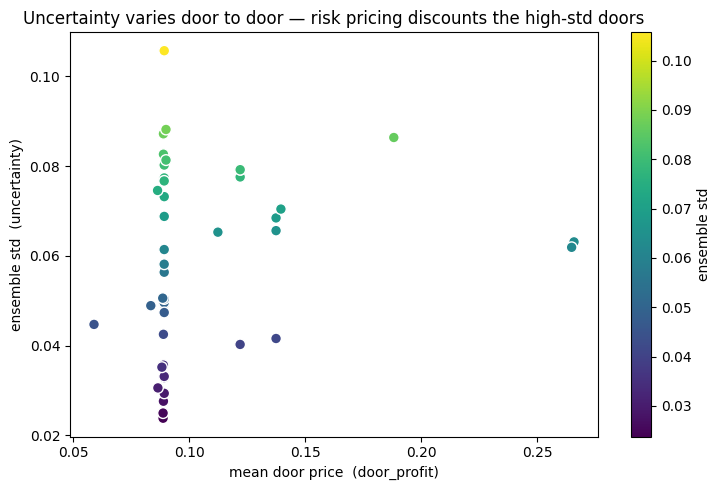

In [4]:
orch0 = make_orch(0.0)
orch1 = make_orch(1.0)
doors = _dense_block(N_DOORS, settings, SEED, radius_km=0.3)

mean_price = np.array([orch0.door_profit(d) for d in doors])
# std recovered from the shipped API: risk(kappa=1) = mean - 1.0*std  =>  std = mean - risk(kappa=1).
risk_std = np.array([orch1.door_profit(d) - orch1.door_profit_risk(d) for d in doors])

# The exact no-op: at kappa=0, risk price == door_profit to the bit.
noop_gap = max(abs(orch0.door_profit_risk(d) - orch0.door_profit(d)) for d in doors)
print(f"kappa=0 exact no-op:  max |risk_price - door_profit| = {noop_gap:.2e}")
assert noop_gap == 0.0

order = np.argsort(-risk_std)[:5]
print("\nmost-uncertain doors (mean price vs risk price):")
header = "   idx     mean   std   " + "  ".join(f"k={k}" for k in KAPPAS)
print(header)
for i in order:
    prices = [make_orch(k).door_profit_risk(doors[i]) for k in KAPPAS]
    print(
        f"  #{int(i):>3}  {mean_price[i]:+.3f}  {risk_std[i]:.3f}  "
        + "  ".join(f"{p:+.2f}" for p in prices)
    )

fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(mean_price, risk_std, c=risk_std, cmap="viridis", s=60, edgecolors="white")
ax.set_xlabel("mean door price  (door_profit)")
ax.set_ylabel("ensemble std  (uncertainty)")
ax.set_title("Uncertainty varies door to door — risk pricing discounts the high-std doors")
fig.colorbar(sc, label="ensemble std")
plt.tight_layout()

## 4. Route effect: risk pricing swaps uncertain doors for surer ones

On the *same* territory with a binding capacity, we route once with mean pricing (`kappa = 0`) and
once with a moderate risk appetite (`KAPPA_MAP` below). The served sets differ: the risk router
**drops some high-uncertainty doors the mean router kept** and picks up surer ones instead. The map
sizes each door by its ensemble std, so the swap is visible — the doors the risk router gives up are
the big (uncertain) ones. (Crank `kappa` far enough and it drops *most* doors — caution has a price,
which is the whole point of section 5.)

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

mean pricing  served 25 doors
risk pricing  served 25 doors  (kappa=0.5)
swapped OUT by risk (uncertain): 1 doors
  their mean ensemble std = 0.073
  swapped-in doors std    = 0.033


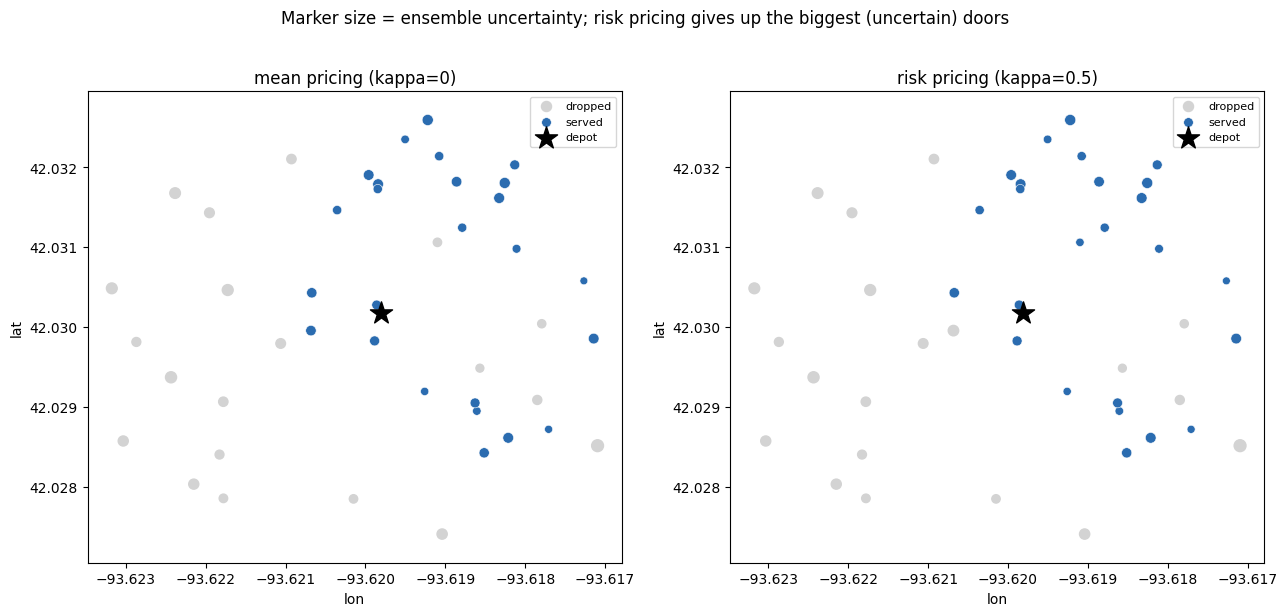

In [5]:
KAPPA_MAP = 0.5
route_mean = orch0.plan_route(doors)
route_risk = make_orch(KAPPA_MAP).plan_route(doors)
assert not isinstance(route_mean, list) and not isinstance(route_risk, list)

served_mean, served_risk = set(route_mean.visited), set(route_risk.visited)
swapped_out = sorted(served_mean - served_risk)  # kept by mean pricing, dropped by risk pricing
swapped_in = sorted(served_risk - served_mean)

print(f"mean pricing  served {len(served_mean)} doors")
print(f"risk pricing  served {len(served_risk)} doors  (kappa={KAPPA_MAP})")
print(f"swapped OUT by risk (uncertain): {len(swapped_out)} doors")
if swapped_out:
    print(f"  their mean ensemble std = {np.mean([risk_std[n - 1] for n in swapped_out]):.3f}")
if swapped_in:
    print(f"  swapped-in doors std    = {np.mean([risk_std[n - 1] for n in swapped_in]):.3f}")

coords = np.array([(d.lat, d.lon) for d in doors])
depot = coords.mean(axis=0)


def plot_route_map(ax, served, title):
    dropped = [n for n in range(1, N_DOORS + 1) if n not in served]
    if dropped:
        idx = [n - 1 for n in dropped]
        ax.scatter(coords[idx, 1], coords[idx, 0], s=20 + 500 * risk_std[idx],
                   c="lightgray", label="dropped", zorder=2)
    idx = [n - 1 for n in sorted(served)]
    ax.scatter(coords[idx, 1], coords[idx, 0], s=20 + 500 * risk_std[idx],
               c="#2b6cb0", edgecolors="white", linewidths=0.4, label="served", zorder=3)
    ax.scatter(depot[1], depot[0], marker="*", s=280, c="black", label="depot", zorder=5)
    ax.set_title(title)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_aspect("equal", adjustable="datalim")


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_route_map(axes[0], served_mean, "mean pricing (kappa=0)")
plot_route_map(axes[1], served_risk, f"risk pricing (kappa={KAPPA_MAP})")
fig.suptitle("Marker size = ensemble uncertainty; risk pricing gives up the biggest (uncertain) doors",
             y=1.02)
plt.tight_layout()

## 5. Simulate & compare: the risk-return frontier

Now the yardstick from doc 11 section 10. For each `kappa` we walk `N_SHIFTS` simulated shifts on the
real oracle — plan the (risk-priced) route, recommend, sample the outcome, bank the reward — and
collect the **realized shift value**. Each shift's doors and outcome noise are seeded identically
across `kappa`, so the *only* difference is the pricing rule.

We then compare the distribution's **mean** (are we giving up value?) against its **std** and
**CVaR** (are we shrinking downside?). This is exactly what `scripts/run_experiment.py` records on
the append-only leaderboard — the notebook just lets you *see* the frontier and vary `kappa`
interactively.

In [6]:
def _cvar(vals: np.ndarray, alpha: float) -> float:
    v = np.sort(vals)
    k = max(1, int(np.ceil(alpha * v.size)))
    return float(v[:k].mean())


def realized_value(orch: Orchestrator, shift_doors, oracle, rng) -> float:
    """Walk the (risk-priced) planned route, banking the true reward of every serviced door."""
    plan = orch.plan_route(shift_doors)
    total = 0.0
    for door in _plan_to_doors(plan, shift_doors):
        res = orch.recommend(door)
        outcome = oracle.sample_outcome(door, res.action, rng)
        orch.feedback(res.decision_id, outcome)
        total += REWARD[outcome]
    return total


orchs = {k: make_orch(k) for k in KAPPAS}
realized: dict[float, list[float]] = {k: [] for k in KAPPAS}

for s in range(N_SHIFTS):
    shift_doors = _dense_block(N_DOORS, settings, seed=SEED + 100 + s)
    if DATASET_MODE == "relational":
        world = rel.world_from_contexts(shift_doors, settings=settings, seed=SEED + 100 + s)
        oracle = oracle_for(settings, world=world)
    else:
        oracle = oracle_for(settings)
    for k in KAPPAS:
        rng = np.random.default_rng(9000 + s)  # same outcome noise across kappa
        realized[k].append(realized_value(orchs[k], shift_doors, oracle, rng))

print(f"{N_SHIFTS} shifts x {len(KAPPAS)} kappa values simulated on the {DATASET_MODE} oracle\n")
print(f"{'kappa':>6} {'mean':>9} {'std':>9} {'CVaR':>9}   (std/CVaR: lower = more robust)")
stats = {}
for k in KAPPAS:
    arr = np.asarray(realized[k], dtype=np.float64)
    stats[k] = (arr.mean(), arr.std(), _cvar(arr, CVAR_ALPHA))
    print(f"{k:>6.2f} {stats[k][0]:>9.3f} {stats[k][1]:>9.3f} {stats[k][2]:>9.3f}")

print("\nkappa=0 is the mean-pricing baseline (exact door-level no-op verified in section 3).")

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

...

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

8 shifts x 4 kappa values simulated on the flat oracle

 kappa      mean       std      CVaR   (std/CVaR: lower = more robust)
  0.00     2.787     1.621     0.800
  0.50     2.475     1.178     0.800
  1.00     2.250     1.931     0.100
  2.00     0.237     0.312     0.000

kappa=0 is the mean-pricing baseline (exact door-level no-op verified in section 3).


/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/avist/Projects/nba/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor wa

lowest realized-value std at kappa=2.0 (std 0.312 vs baseline 1.621); mean there 0.237 vs baseline 2.787


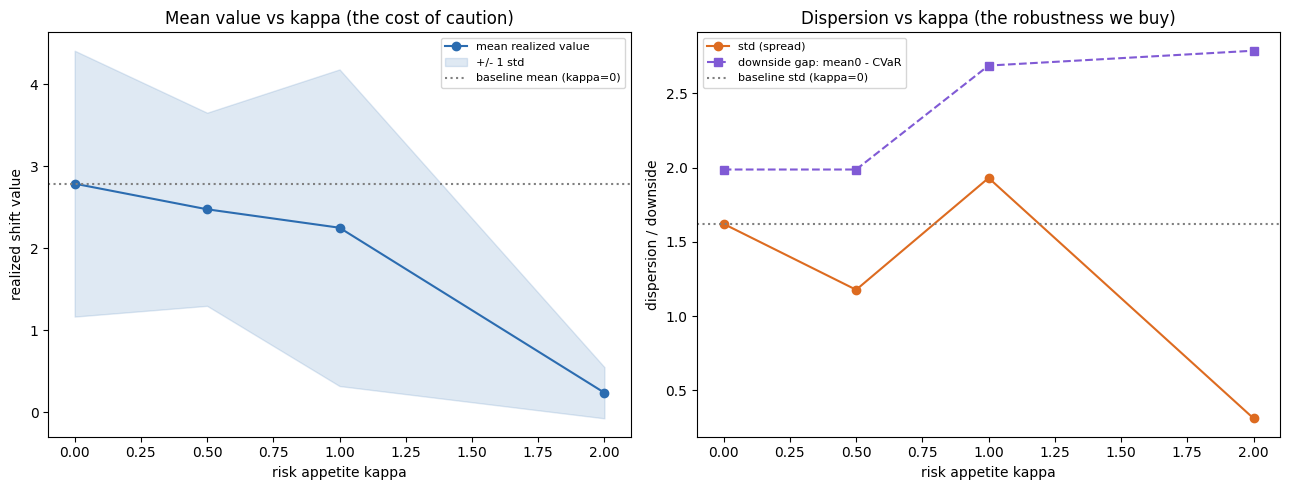

In [7]:
ks = np.array(KAPPAS)
means = np.array([stats[k][0] for k in KAPPAS])
stds = np.array([stats[k][1] for k in KAPPAS])
cvars = np.array([stats[k][2] for k in KAPPAS])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(ks, means, "o-", color="#2b6cb0", label="mean realized value")
ax1.fill_between(ks, means - stds, means + stds, color="#2b6cb0", alpha=0.15, label="+/- 1 std")
ax1.axhline(means[0], ls=":", color="gray", label="baseline mean (kappa=0)")
ax1.set_xlabel("risk appetite kappa")
ax1.set_ylabel("realized shift value")
ax1.set_title("Mean value vs kappa (the cost of caution)")
ax1.legend(fontsize=8)

ax2.plot(ks, stds, "o-", color="#dd6b20", label="std (spread)")
ax2.plot(ks, means[0] - cvars, "s--", color="#805ad5", label="downside gap: mean0 - CVaR")
ax2.axhline(stds[0], ls=":", color="gray", label="baseline std (kappa=0)")
ax2.set_xlabel("risk appetite kappa")
ax2.set_ylabel("dispersion / downside")
ax2.set_title("Dispersion vs kappa (the robustness we buy)")
ax2.legend(fontsize=8)

plt.tight_layout()

best_std_k = KAPPAS[int(np.argmin(stds))]
print(f"lowest realized-value std at kappa={best_std_k} "
      f"(std {stds.min():.3f} vs baseline {stds[0]:.3f}); "
      f"mean there {stats[best_std_k][0]:.3f} vs baseline {means[0]:.3f}")

## 6. Takeaways

- **`kappa = 0` is a proven exact no-op** (section 3), so `NBA_USE_RISK_AWARE_ROUTING` ships off by
  default and touches nothing until you tune `NBA_RISK_KAPPA`.
- **Risk pricing is a localized change**: only the door *prize* changes (`door_profit_risk` instead
  of `door_profit`); the same `solve_tsp_profits` consumes it, so routing, OPE, and the event store
  are untouched.
- **Risk vs return is a dial, not a free lunch.** Raising `kappa` deprioritizes the doors the model
  is least sure about. Whether that *reduces realized-value dispersion at comparable mean* depends on
  the regime: it only bites when capacity/budget binds so the served set actually changes, and when
  the ensemble's epistemic uncertainty lines up with real downside. Read the frontier above before
  choosing a `kappa`.
- **The `cvar` objective** (`NBA_RISK_OBJECTIVE=cvar`) is the strictly-more-conservative option:
  price each door by the mean of its worst-`cvar_alpha` ensemble scenarios. It has no no-op setting
  and targets tail protection directly. Re-run `make_orch(0.0, objective="cvar")` to compare.
- **The authoritative verdict lives on the leaderboard.** `scripts/run_experiment.py` grades
  `phase11-risk-kappaX` against the `baseline` and writes `artifacts/leaderboard.md`; this notebook
  is its interactive companion. Per doc 11 section 10 this upgrade is judged on downside
  (std / CVaR) at comparable mean, so its leaderboard verdict is expected to be a documented
  **neutral on the primary mean** unless a `kappa` both lifts value and clears the DR gate.

Knobs to explore: tighten `SHIFT_CAPACITY` (more binding => risk pricing matters more), widen
`KAPPAS`, flip `DATASET_MODE` to `"relational"`, or switch to the `cvar` objective.